## Knn for channel estimation

In [1]:
import torch
import sys
import torch.nn as nn
sys.path.append("../")

from datasets.dataloader import get_wireless_dataloader

# Positional Encoding (kept the same for consistency)
class PositionalEncoding(nn.Module):
    def __init__(self, num_freqs=10, input_dim=3):
        super(PositionalEncoding, self).__init__()
        self.num_freqs = num_freqs
        # Each input dimension is encoded as:
        # original value + sin(2^i * x) + cos(2^i * x) for i in 0,...,num_freqs-1
        self.output_dim = input_dim * (2 * num_freqs + 1)

    def forward(self, x):
        """Handles batched inputs (B, 3) correctly"""
        B, D = x.shape  # B: Batch size, D: Input dim (should be 3)
        freqs = 2 ** torch.arange(self.num_freqs, dtype=torch.float32, device=x.device)
        x_expanded = x.unsqueeze(-1) * freqs  
        x_original = x.unsqueeze(-1)
        x_encoded = torch.cat([x_original, torch.sin(x_expanded), torch.cos(x_expanded)], dim=-1)
        return x_encoded.view(B, -1)

# KNN Channel Estimator
class KNNChannelEstimator(nn.Module):
    def __init__(self, train_positions, train_channels, k=3, num_freqs=10, input_dim=3, tx_ant=16, rx_ant=2):
        """
        Args:
            train_positions: Tensor of shape [N, 3] with training receiver positions.
            train_channels: Tensor of shape [N, tx_ant, rx_ant, 2] with corresponding channel matrices.
            k: Number of nearest neighbors to use (here, 3).
        """
        super(KNNChannelEstimator, self).__init__()
        self.k = k
        self.tx_ant = tx_ant
        self.rx_ant = rx_ant
        self.pos_encoding = PositionalEncoding(num_freqs=num_freqs, input_dim=input_dim)
        # Precompute and store the encoded training positions.
        self.register_buffer("encoded_train_positions", self.pos_encoding(train_positions))
        # Store the training channel matrices.
        self.register_buffer("train_channels", train_channels)

    def forward(self, x):
        """
        Args:
            x: Query receiver positions, Tensor of shape [B, 3].
        Returns:
            Estimated channel matrices of shape [B, tx_ant, rx_ant, 2].
        """
        # Encode the query positions using the same positional encoding.
        x_encoded = self.pos_encoding(x)
        # Compute pairwise Euclidean distances between each query and all training positions.
        dists = torch.cdist(x_encoded, self.encoded_train_positions)  # Shape: [B, N]
        # Get indices of the k smallest distances (nearest neighbors).
        _, knn_indices = torch.topk(dists, k=self.k, largest=False)
        # Gather the channel matrices of the k nearest neighbors.
        # The result has shape [B, k, tx_ant, rx_ant, 2]
        knn_channels = self.train_channels[knn_indices]
        # Average the k channel matrices to obtain the final estimate.
        avg_channels = torch.mean(knn_channels, dim=1)  # Shape: [B, tx_ant, rx_ant, 2]
        return avg_channels

# Load the dataset
dataloader = get_wireless_dataloader(
    "../datasets/outputs/conf_16x2_414u_5.0ghz_sbrRT_sc104.mat",
    batch_size=16,
    num_pc=16378,
    drop_last=True
)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Accumulate the entire training dataset for KNN.
all_rx_positions = []
all_channel_matrices = []
for batch in dataloader:
    all_rx_positions.append(batch["rx_position"].to(device))
    all_channel_matrices.append(batch["channel_matrix"].to(device))
# Concatenate all batches along the first dimension.
train_positions = torch.cat(all_rx_positions, dim=0)  # [N, 3]
train_channels = torch.cat(all_channel_matrices, dim=0)  # [N, tx_ant, rx_ant, 2]

tx_ant, rx_ant = 16, 2
# Initialize the KNN estimator with k=3.
model = KNNChannelEstimator(train_positions, train_channels, k=3, num_freqs=10, input_dim=3, tx_ant=tx_ant, rx_ant=rx_ant).to(device)

criterion = nn.MSELoss()  # Using MSE for evaluation

# Since KNN is non-parametric, we simply evaluate on the (training) data.
total_loss = 0.0
num_batches = 0
for batch in dataloader:
    rx_positions = batch["rx_position"].to(device)
    channel_matrix = batch["channel_matrix"].to(device)
    
    # Obtain predictions via KNN
    predicted_channel = model(rx_positions)
    loss = criterion(predicted_channel, channel_matrix)
    total_loss += loss.item()
    num_batches += 1

avg_loss = total_loss / num_batches
print(f"Average MSE Loss: {avg_loss:.6f}")

# Save the "model" (which includes the training data and parameters for KNN).
torch.save(model.state_dict(), "knn_channel_estimator.pth")
print("Evaluation complete. Model saved.")


Average MSE Loss: 0.000003
Evaluation complete. Model saved.


# Inference

Batch 0: NMSE = 1.380480, SNR = -1.40 dB
Batch 1: NMSE = 1.268228, SNR = -1.03 dB
Batch 2: NMSE = 1.185066, SNR = -0.74 dB
Batch 3: NMSE = 1.163797, SNR = -0.66 dB
Batch 4: NMSE = 1.457833, SNR = -1.64 dB


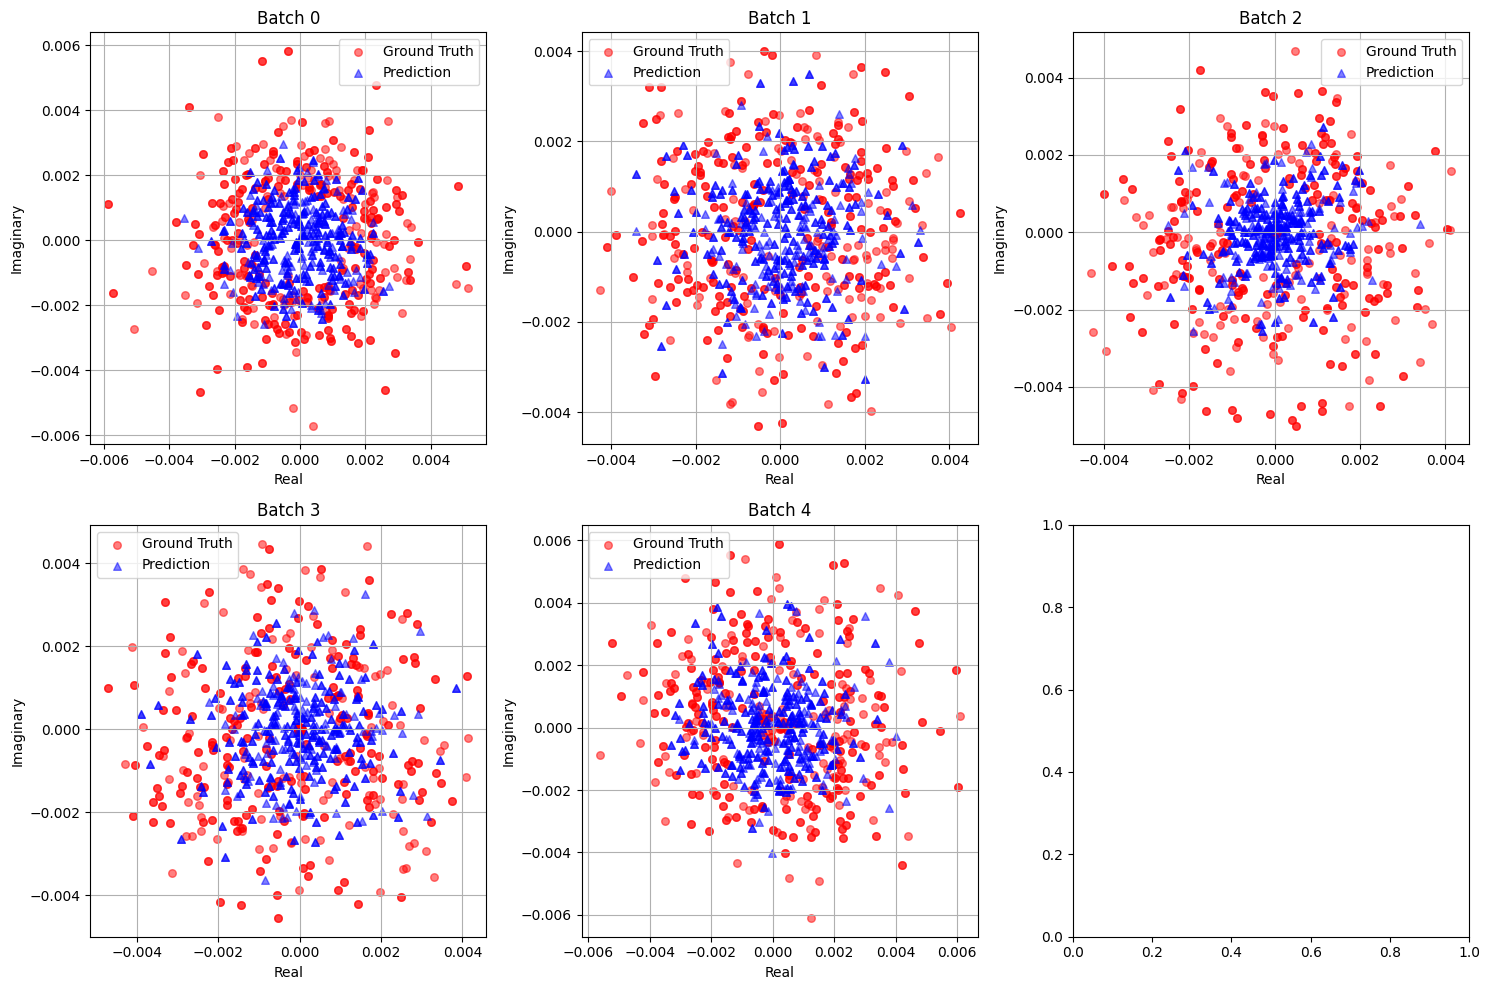

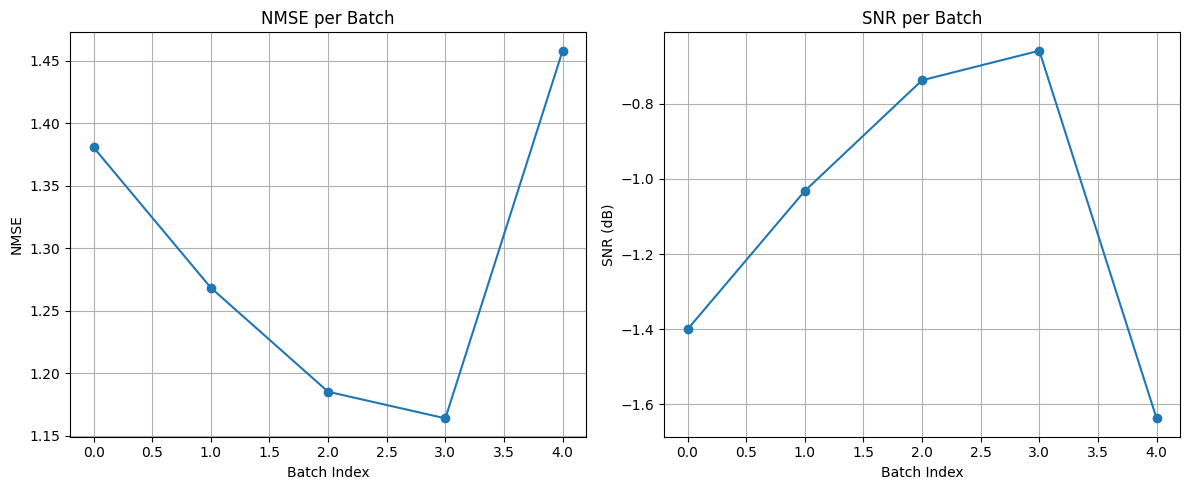

Average SNR over 5 batches: -1.09 dB


In [2]:
import torch
import matplotlib.pyplot as plt
import sys
import torch.nn as nn
import numpy as np
sys.path.append("../")
from datasets.dataloader import get_wireless_dataloader

# Define Positional Encoding (same as used during training)
class PositionalEncoding(nn.Module):
    def __init__(self, num_freqs=10, input_dim=3):
        super(PositionalEncoding, self).__init__()
        self.num_freqs = num_freqs
        # Output dimension: original + sin + cos for each frequency
        self.output_dim = input_dim * (2 * num_freqs + 1)

    def forward(self, x):
        B, D = x.shape
        freqs = 2 ** torch.arange(self.num_freqs, dtype=torch.float32, device=x.device)
        x_expanded = x.unsqueeze(-1) * freqs   # Shape: [B, 3, num_freqs]
        x_original = x.unsqueeze(-1)           # Shape: [B, 3, 1]
        x_encoded = torch.cat([x_original, torch.sin(x_expanded), torch.cos(x_expanded)], dim=-1)
        return x_encoded.view(B, -1)

# Define KNN Channel Estimator
class KNNChannelEstimator(nn.Module):
    def __init__(self, train_positions, train_channels, k=3, num_freqs=10, input_dim=3, tx_ant=16, rx_ant=2):
        """
        Args:
            train_positions: Tensor of shape [N, 3] with training receiver positions.
            train_channels: Tensor of shape [N, tx_ant, rx_ant, 2] with corresponding channel matrices.
            k: Number of nearest neighbors to use.
        """
        super(KNNChannelEstimator, self).__init__()
        self.k = k
        self.tx_ant = tx_ant
        self.rx_ant = rx_ant
        self.pos_encoding = PositionalEncoding(num_freqs=num_freqs, input_dim=input_dim)
        # Precompute and store the encoded training positions.
        self.register_buffer("encoded_train_positions", self.pos_encoding(train_positions))
        # Store the training channel matrices.
        self.register_buffer("train_channels", train_channels)

    def forward(self, x):
        # Encode the query receiver positions.
        x_encoded = self.pos_encoding(x)
        # Compute Euclidean distances between each query and all training positions.
        dists = torch.cdist(x_encoded, self.encoded_train_positions)  # Shape: [B, N]
        # Find indices of the k smallest distances (nearest neighbors).
        _, knn_indices = torch.topk(dists, k=self.k, largest=False)
        # Gather channel matrices of the k nearest neighbors: [B, k, tx_ant, rx_ant, 2]
        knn_channels = self.train_channels[knn_indices]
        # Average over the k neighbors to estimate the channel matrix.
        avg_channels = torch.mean(knn_channels, dim=1)  # Shape: [B, tx_ant, rx_ant, 2]
        return avg_channels

# Load test dataset
test_dataloader = get_wireless_dataloader(
    "../datasets/outputs/conf_16x2_414u_5.0ghz_sbrRT_sc104.mat",
    batch_size=16,
    num_pc=16378,
    drop_last=True,
    train=False
)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tx_ant, rx_ant = 16, 2

# Load training dataset to initialize the KNN model with the correct training data
train_dataloader = get_wireless_dataloader(
    "../datasets/outputs/conf_16x2_414u_5.0ghz_sbrRT_sc104.mat",
    batch_size=16,
    num_pc=16378,
    drop_last=True,
    train=True
)

all_train_positions = []
all_train_channels = []
for batch in train_dataloader:
    all_train_positions.append(batch["rx_position"].to(device))
    all_train_channels.append(batch["channel_matrix"].to(device))
train_positions = torch.cat(all_train_positions, dim=0)  # Expected shape: [320, 3]
train_channels = torch.cat(all_train_channels, dim=0)      # Expected shape: [320, tx_ant, rx_ant, 2]

# Initialize the KNN model with the training data
model = KNNChannelEstimator(train_positions, train_channels,
                            k=3, num_freqs=10, input_dim=3,
                            tx_ant=tx_ant, rx_ant=rx_ant).to(device)

# Load the saved state; now the buffer shapes match
model.load_state_dict(torch.load("knn_channel_estimator.pth", map_location=device))
model.eval()

# Create a figure with subplots for scatter plots (for a few batches)
num_batches_to_plot = 6
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()

# Lists to store NMSE and SNR values for each batch
nmse_list = []
snr_list = []
batch_indices = []

# Process multiple batches
for batch_idx, batch in enumerate(test_dataloader):
    if batch_idx >= num_batches_to_plot:
        break
        
    rx_positions = batch["rx_position"].to(device)           # [B, 3]
    channel_matrix = batch["channel_matrix"].to(device)        # [B, tx_ant, rx_ant, 2]
    
    with torch.no_grad():
        predicted_channel = model(rx_positions)                # [B, tx_ant, rx_ant, 2]
    
    # Compute NMSE: mean(|H_pred - H_gt|^2) / mean(|H_gt|^2)
    mse = torch.mean((predicted_channel - channel_matrix) ** 2)
    norm = torch.mean(channel_matrix ** 2)
    nmse = mse / norm
    nmse_value = nmse.item()
    # SNR (dB) = -10 * log10(NMSE)
    snr_value = -10 * np.log10(nmse_value)
    
    nmse_list.append(nmse_value)
    snr_list.append(snr_value)
    batch_indices.append(batch_idx)
    
    print(f"Batch {batch_idx}: NMSE = {nmse_value:.6f}, SNR = {snr_value:.2f} dB")
    
    # Extract real and imaginary parts for scatter plot
    gt_real = channel_matrix[..., 0].cpu().numpy()
    gt_imag = channel_matrix[..., 1].cpu().numpy()
    pred_real = predicted_channel[..., 0].cpu().numpy()
    pred_imag = predicted_channel[..., 1].cpu().numpy()
    
    # Flatten arrays for scatter plot
    gt_r = gt_real.flatten()
    gt_i = gt_imag.flatten()
    pr_r = pred_real.flatten()
    pr_i = pred_imag.flatten()
    
    # Create scatter plot for this batch
    ax = axs[batch_idx]
    ax.scatter(gt_r, gt_i, color='red', marker='o', label='Ground Truth', alpha=0.5, s=30)
    ax.scatter(pr_r, pr_i, color='blue', marker='^', label='Prediction', alpha=0.5, s=30)
    ax.set_xlabel("Real")
    ax.set_ylabel("Imaginary")
    ax.set_title(f"Batch {batch_idx}")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# Plot NMSE and SNR versus batch index
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(batch_indices, nmse_list, marker='o', linestyle='-')
plt.xlabel("Batch Index")
plt.ylabel("NMSE")
plt.title("NMSE per Batch")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(batch_indices, snr_list, marker='o', linestyle='-')
plt.xlabel("Batch Index")
plt.ylabel("SNR (dB)")
plt.title("SNR per Batch")
plt.grid(True)

plt.tight_layout()
plt.show()

avg_snr = np.mean(snr_list)
print(f"Average SNR over {len(snr_list)} batches: {avg_snr:.2f} dB")
